In [1]:
!pip install featuretools shap xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.9/587.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 9.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_absolute_error

from xgboost import XGBRegressor

import featuretools as ft
import shap

In [3]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Target"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.loc[
    np.random.choice(df.index, 500),
    "AveRooms"
] = np.nan

df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,494
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Target,0


In [5]:
imputer = SimpleImputer(
    strategy="median"
)

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

df_imputed.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
Q1 = df_imputed.quantile(0.25)
Q3 = df_imputed.quantile(0.75)

IQR = Q3 - Q1

df_clean = df_imputed[
    ~(
        (
            df_imputed <
            (Q1 - 1.5 * IQR)
        ) |
        (
            df_imputed >
            (Q3 + 1.5 * IQR)
        )
    ).any(axis=1)
]

print(df_clean.shape)

(16298, 9)


In [7]:
es = ft.EntitySet(
    id="housing"
)

es = es.add_dataframe(
    dataframe_name="data",
    dataframe=df_clean,
    index="index",
    make_index=True
)

feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="data",
    max_depth=2
)

feature_matrix.head()

/usr/local/lib/python3.12/dist-packages/featuretools/synthesis/deep_feature_synthesis.py:169: UserWarning: Only one dataframe in entityset, changing max_depth to 1 since deeper features cannot be created
  warnings.warn(


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
index,,,,,,,,,
0,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
1,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
2,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
3,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
4,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992


In [8]:
feature_matrix["Income_Per_Room"] = (
    feature_matrix["MedInc"] /
    feature_matrix["AveRooms"]
)

feature_matrix["Occupancy_Density"] = (
    feature_matrix["Population"] /
    feature_matrix["AveOccup"]
)

feature_matrix.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target,Income_Per_Room,Occupancy_Density
index,,,,,,,,,,,
0,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.875637,177.0
1,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0.970046,219.0
2,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0.612272,259.0
3,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697,0.847772,193.0
4,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992,0.741924,514.0


In [9]:
X = feature_matrix.drop(
    "Target",
    axis=1,
    errors="ignore"
)

y = feature_matrix["Target"]

selector = SelectKBest(
    score_func=f_regression,
    k=10
)

X_selected = selector.fit_transform(
    X,
    y
)

selected_features = X.columns[
    selector.get_support()
]

print(selected_features)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Income_Per_Room', 'Occupancy_Density'],
      dtype='object')


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features],
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
models = {
    "Random Forest":
    RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost":
    XGBRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    r2 = r2_score(
        y_test,
        pred
    )

    mae = mean_absolute_error(
        y_test,
        pred
    )

    results.append(
        [name, r2, mae]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R2",
        "MAE"
    ]
)

results_df

,Model,R2,MAE
0,Random Forest,0.770215,0.301904
1,XGBoost,0.802364,0.281427


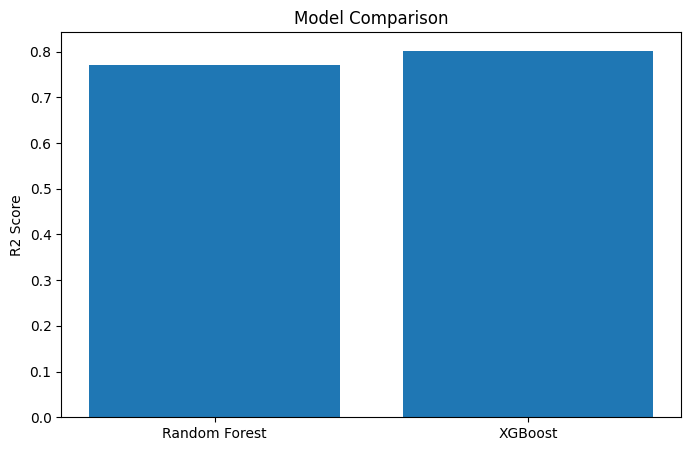

In [12]:
plt.figure(
    figsize=(8,5)
)

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.title(
    "Model Comparison"
)

plt.ylabel(
    "R2 Score"
)

plt.show()

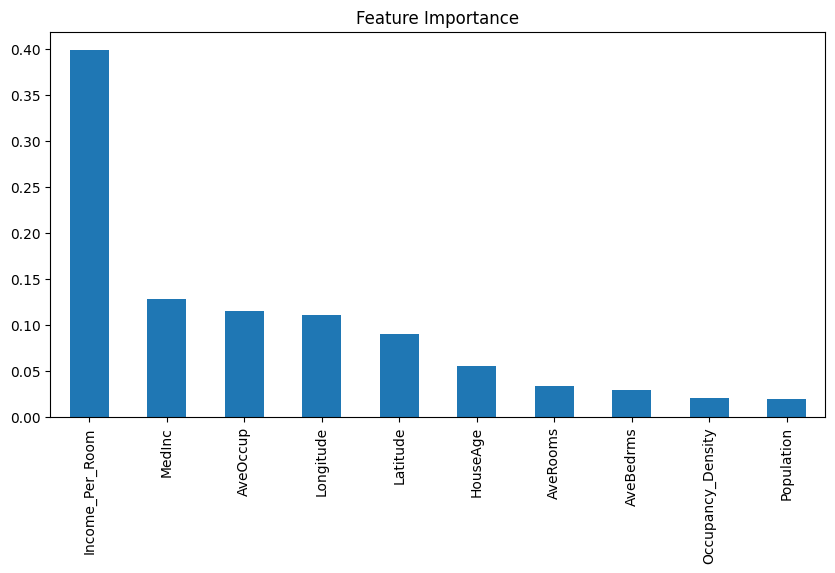

In [13]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

importance = pd.Series(
    rf.feature_importances_,
    index=selected_features
)

importance.sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Feature Importance"
)

plt.show()

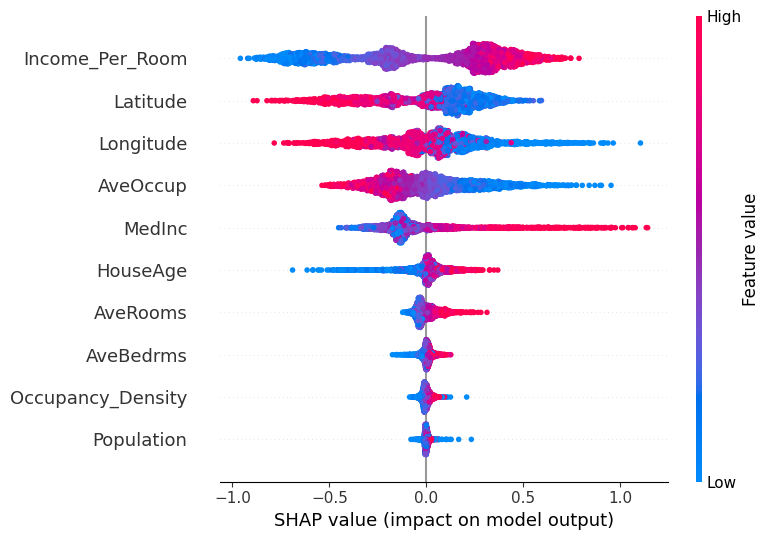

In [14]:
explainer = shap.TreeExplainer(
    rf
)

shap_values = explainer.shap_values(
    X_test
)

shap.summary_plot(
    shap_values,
    X_test
)

In [15]:
print("="*50)

print("AI DATASET ENHANCEMENT REPORT")

print("="*50)

print("\nSelected Features:")

print(list(selected_features))

print("\nBenchmark Results:")

print(results_df)

print("\nBest Model:")

best_model = results_df.loc[
    results_df["R2"].idxmax()
]

print(best_model)

AI DATASET ENHANCEMENT REPORT

Selected Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Income_Per_Room', 'Occupancy_Density']

Benchmark Results:
           Model        R2       MAE
0  Random Forest  0.770215  0.301904
1        XGBoost  0.802364  0.281427

Best Model:
Model     XGBoost
R2       0.802364
MAE      0.281427
Name: 1, dtype: object
